# Fashion MNIST classification (Keras)

## Libraries and constants

In [42]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

import torch
from torch.utils.data import TensorDataset, DataLoader
from utils import seed_everything

In [43]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data import

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 24s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


## Data Overview

In [ ]:
# Train/test sizes
print("\nTrain set: ")
print(X_train.shape)
print(y_train.shape)

print("\nTest set: ")
print(X_test.shape)
print(y_test.shape)


Train set: 
(60000, 28, 28)
(60000,)

Test set: 
(10000, 28, 28)
(10000,)


There are only 3 dimensions (num_images, height, width, 1 color channel) - the images are grayscale.

In [8]:
import numpy as np

np.unique(X_train)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

Each image is a numpy array, unnormalized

Train images:


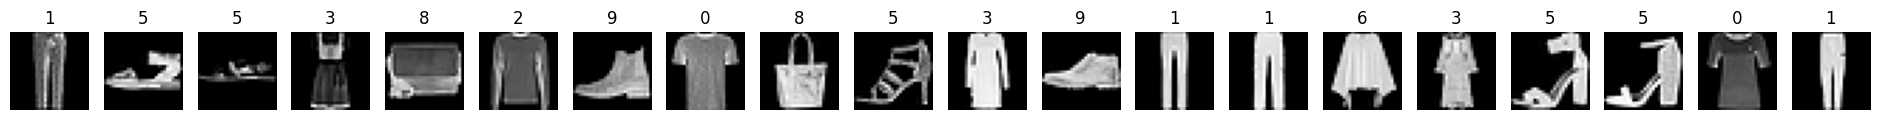

Test images:


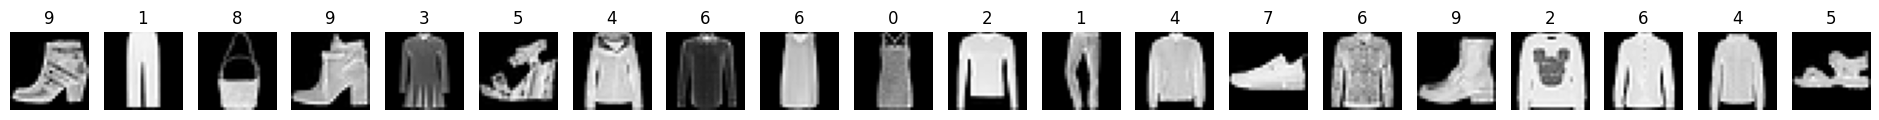

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

def plot_mnist_fashion_images(x_data: np.ndarray, y_data: np.ndarray, num_images: int, rng: np.random.Generator):
    # Select random unique indices using the numpy generator
    random_indices = rng.choice(len(x_data), size=num_images, replace=False)
    
    # Extract, copy, and cast the randomly sampled data
    np_imgs = x_data[random_indices].copy().astype(np.uint8)  # PIL Image expects uint8
    np_labels = y_data[random_indices].copy()

    plt.figure(figsize=(24, 6))
    for i in range(num_images):
        img = Image.fromarray(np_imgs[i], mode="L")               # to PIL grayscale image
        label = np_labels[i]
            
        plt.subplot(
                1,              # a number of rows to plot on
                num_images,     # a number of columns
                i + 1,          # current position to plot in
            )
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

print("Train images:")
plot_mnist_fashion_images(X_train, y_train, 20, rng)

print("Test images:")
plot_mnist_fashion_images(X_test, y_test, 20, rng)

In [15]:
print(f"Train targets: {np.unique(y_train)}")
print(f"Test targets: {np.unique(y_test)}")

Train targets: [0 1 2 3 4 5 6 7 8 9]
Test targets: [0 1 2 3 4 5 6 7 8 9]


Each image represents a fashion item 28x28. The target labels are 10 categorical integers (0-9).

### Class balance

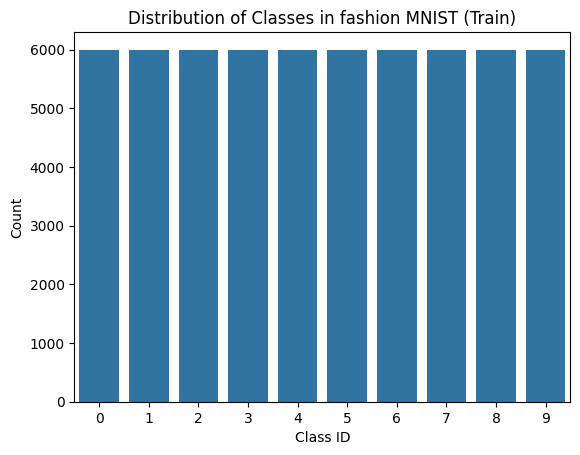

In [16]:
import seaborn as sns

sns.countplot(x=y_train)
plt.title("Distribution of Classes in fashion MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [20]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

The train set is perfectly distributed. No imbalance concerns.

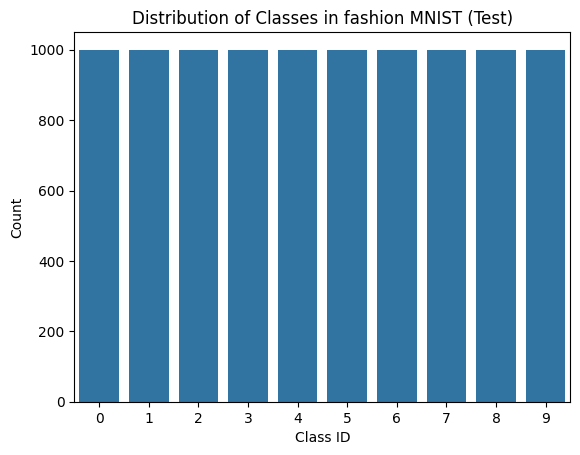

In [21]:
sns.countplot(x=y_test)
plt.title("Distribution of Classes in fashion MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [19]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000],
       dtype=int64))

The test set is perfectly distributed. No imbalance concerns.

### Data representation

The dataset is light and easy, but if we were to face a real problem with huge data that doesn't fit RAM, we would have to move away from np arrays completely. We're going to do it this way.

In [ ]:
# 1. Create standard PyTorch streaming loader
# for simple data just:
# torch_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))

from torch.utils.data import DataLoader, Dataset, Subset  #, random_split

class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()
        self.targets = torch.from_numpy(targets).clone().int()

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target

train_ds  = FashionMNISTDataset(X_train, y_train)
test_ds  = FashionMNISTDataset(X_test, y_test)

Confirming everything's intact.

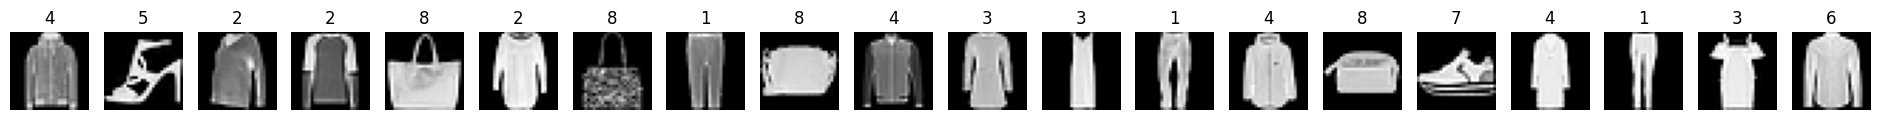

In [55]:
plot_mnist_fashion_images(train_ds.data.numpy(), train_ds.targets.numpy(), 20, rng)

In [38]:
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

Train: 60000, Test: 10000


In [40]:
img, label = train_ds[0]
print(img.shape, label)

torch.Size([28, 28]) tensor(9, dtype=torch.int32)


## Creating and testing loaders

In [44]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [45]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([8, 9, 2,  ..., 0, 0, 0], dtype=torch.int32)


## EDA

### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

In [46]:
# (60000, 28, 28) -> (60000, 784)
train_images_2d = X_train.reshape(-1, 784)

print(f"mnist_train_array_2d.shape = {train_images_2d.shape}")

mnist_train_array_2d.shape = (60000, 784)


In [47]:
from sklearn.ensemble import IsolationForest

# ---------- STEP 1: Fit ----------
iso = IsolationForest(
    n_estimators=500,           # number of random trees
    contamination=0.01,         # expect ~1% anomalies
    max_samples='auto',         # subsample size per tree
    random_state=RANDOM_SEED,
)

iso.fit(train_images_2d)

IsolationForest(contamination=0.01, n_estimators=500, random_state=42)

In [48]:
# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) ----------
flags = iso.predict(train_images_2d)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

Train anomalies flagged: 600


In [49]:
# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(train_images_2d)
print("Top 5 lowest (most anomalous) scores:", sorted(anomaly_score)[:5])

Top 5 lowest (most anomalous) scores: [-0.6934106527099005, -0.6659250893274931, -0.6656201525195374, -0.6626475185657702, -0.662274318689953]


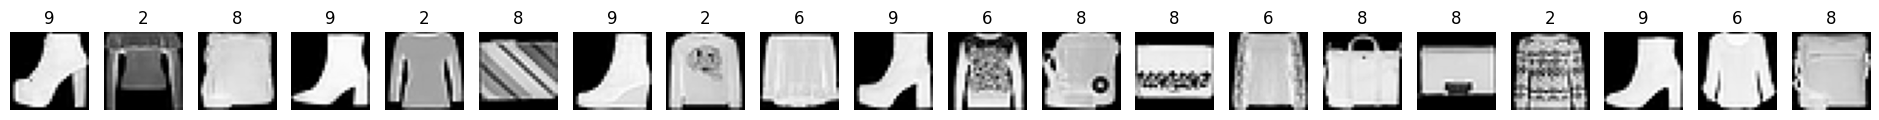

In [ ]:
# ---------- STEP 4: See the flagged images ----------
outlier_idx = np.where(flags == -1)[0]
outliers_mnist_train = np.array([X_train[idx] for idx in outlier_idx])
outlier_targets = np.array([y_train[idx] for idx in outlier_idx])

plot_mnist_fashion_images(outliers_mnist_train, outlier_targets, 20, rng)

All items are recognizable, some corners are cut, noisy backgrounds, even in the worst-flagged images. No outliers present. To fully confirm we do indeed have only the 10 mentioned classes, we'd have to obtain more data. There's not enough evidence to say no side objects present as if the nature of their pixels is similar to our data, Isolation Forest can't discern them.

We cannot mathematically prove there are exactly zero out-of-class items in a 60,000-image dataset unless we look at all 60,000. Instead, we must define a tiny acceptable error threshold. For data science, a standard threshold is fewer than 1% of the data being corrupted/out-of-class. We are going to use Acceptance Sampling.

**The goal**: We want to be 95% confident that the out-of-class rate in the dataset is under 1%.
$H_0$: The dataset **DOES** contain unrelated images. The proportion of unrelated images $p ≥ 0.01$
$H_1$: The dataset **DOES NOT** contain unrelated images. - The proportion of unrelated images $p < 0.01$.

If the true rate of bad images is $1\%$ ($0.01$), then the probability of a randomly picked image being *correct* (fashion) is $99\%$ ($0.99$) each. For a sample size of $n$, the probability of picking $n$ correct images in a row is the product (1st AND 2nd AND 3rd ...): $$p = (0.99)^n \leftarrow \text{Probability of 0 defects}$$
Now, we demand based on the condition and solve:

$$\begin{gather*}
(0.99)^n \le 0.05 \\ \\
\text{Solving for $n$ using logarithms:} \\
\ln(0.99)^n \le \ln(0.05) \\
n \cdot \ln(0.99) \le \ln(0.05) \\
n \ge \frac{\ln(0.05)}{\ln(0.99)} \\ \\
\text{Plug in the values:} \\
n \ge \frac{-2.9957}{-0.01005} \approx 298.07 
\end{gather*}$$

*Decision*: To prove with $95\%$ confidence that the dataset has less than $1\%$ unrelated images, we must **randomly sample and inspect $299$ images**. 
- If we find $0$ unrelated images, we reject $H_0$ and may state with $95\%$ confidence that the overall defect rate is $< 1\%$. > 
- If we find even $1$ unrelated image, we fail to reject $H_0$ and therefore cannot guarantee that the defect rate is below $1\%$.

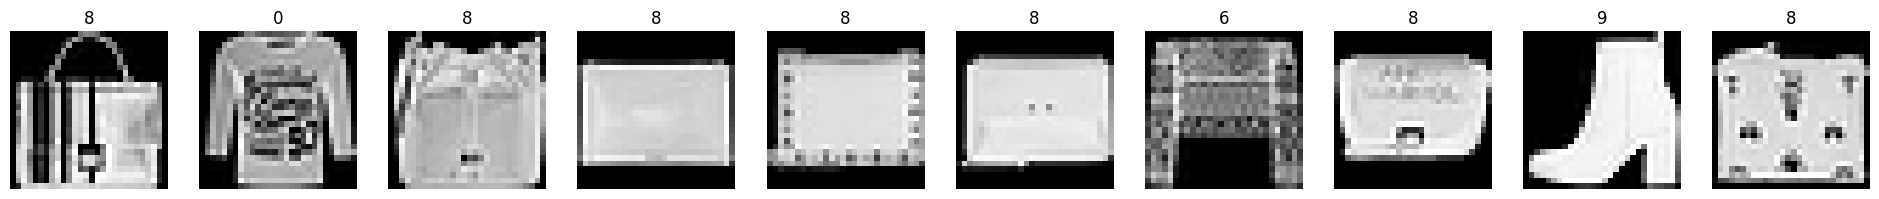

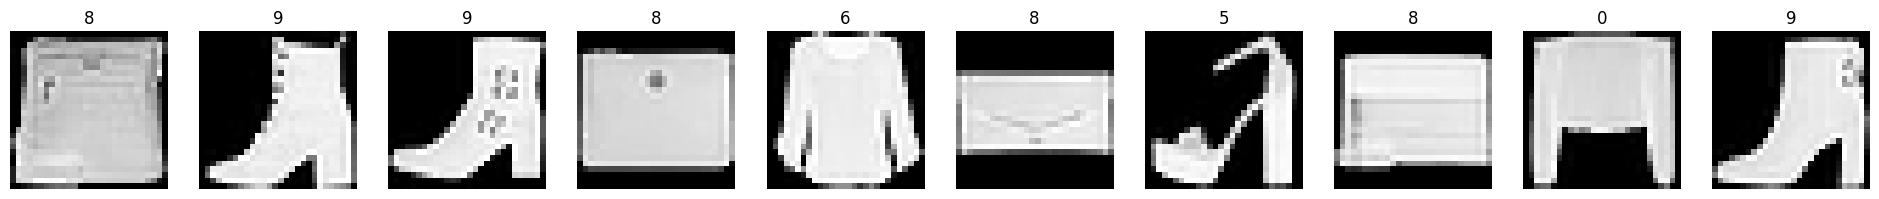

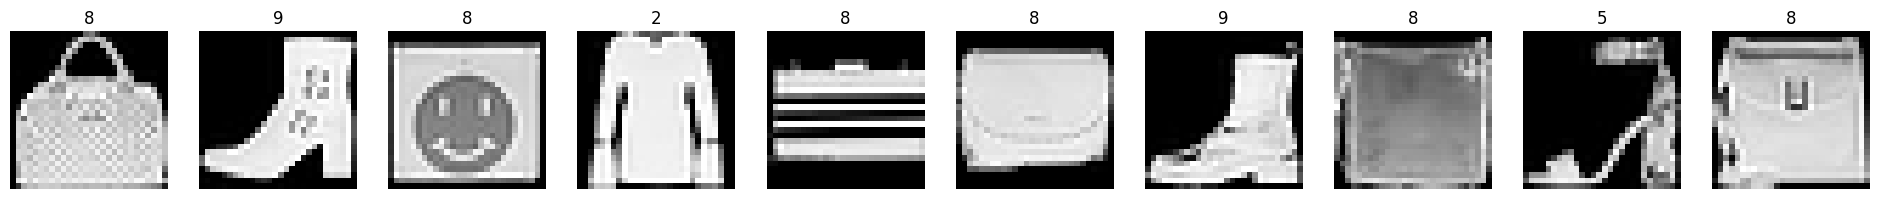

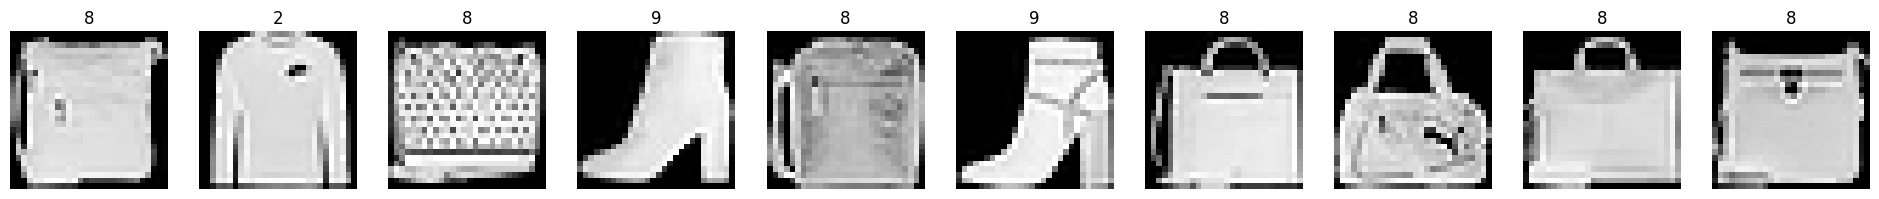

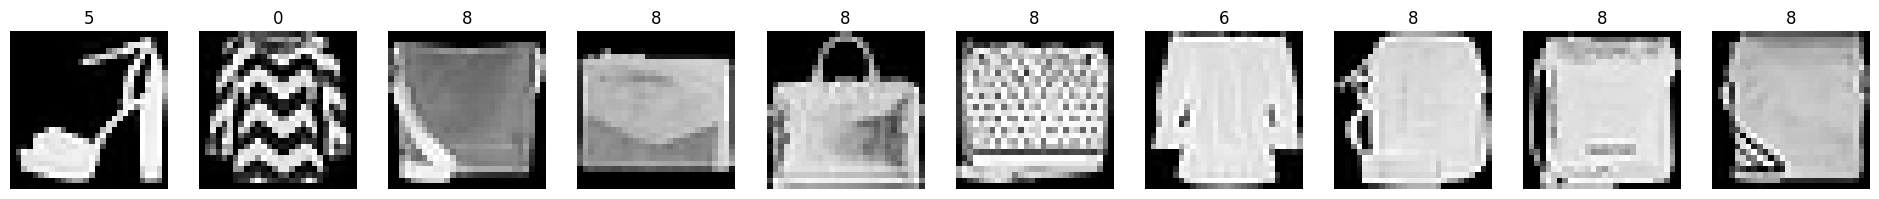

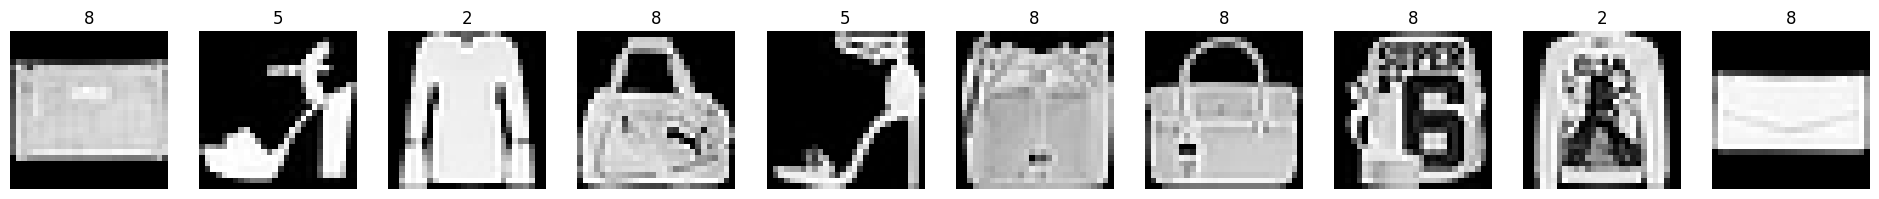

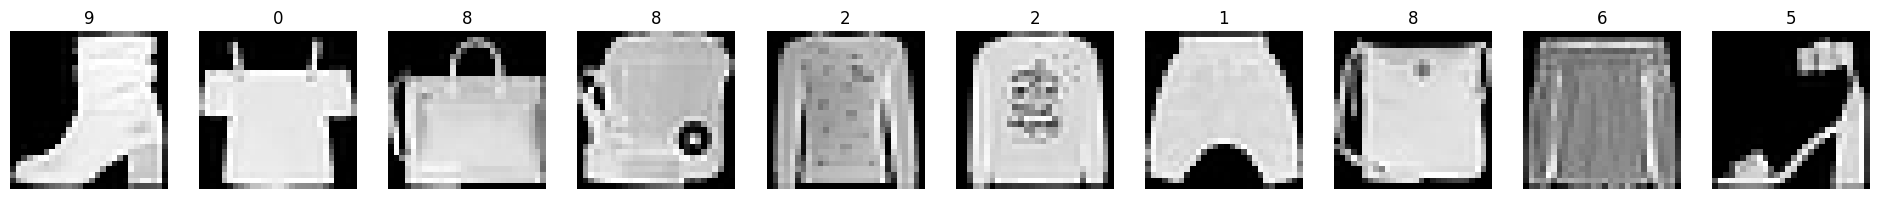

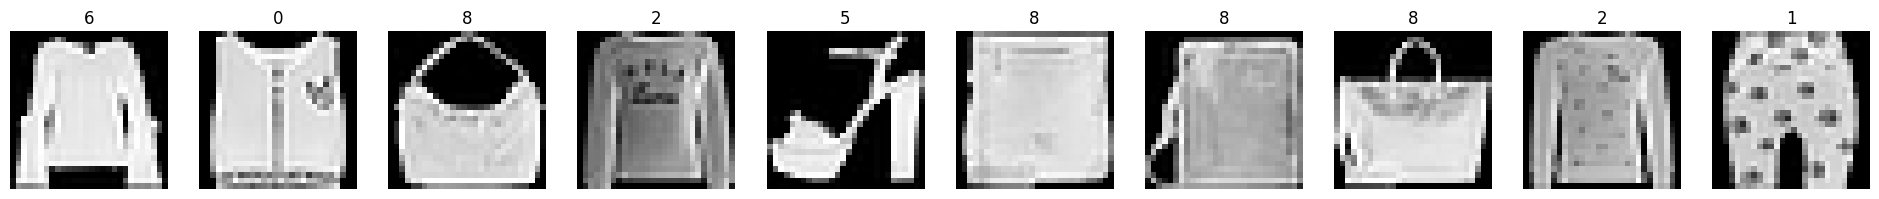

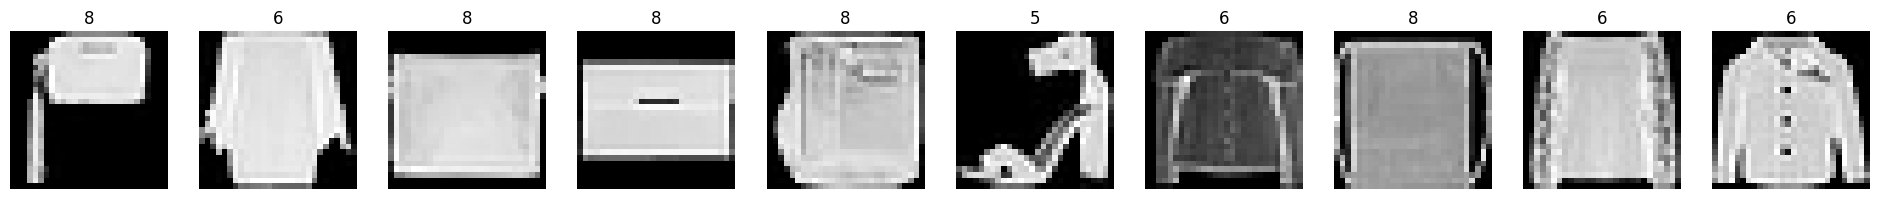

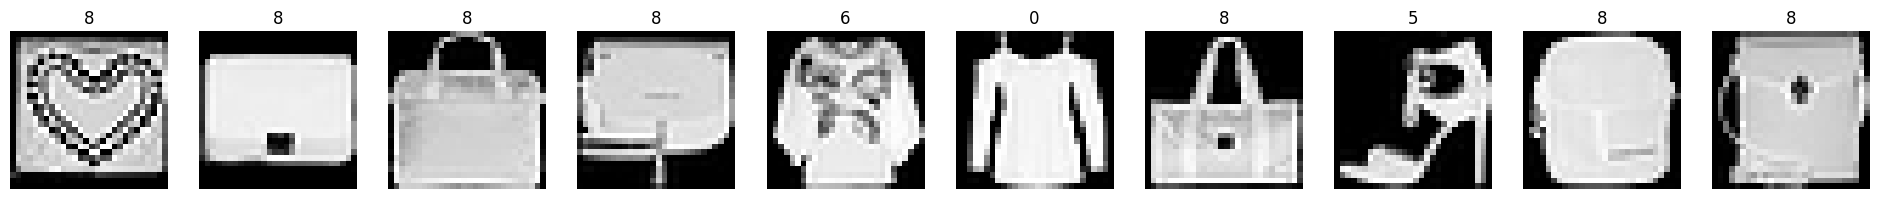

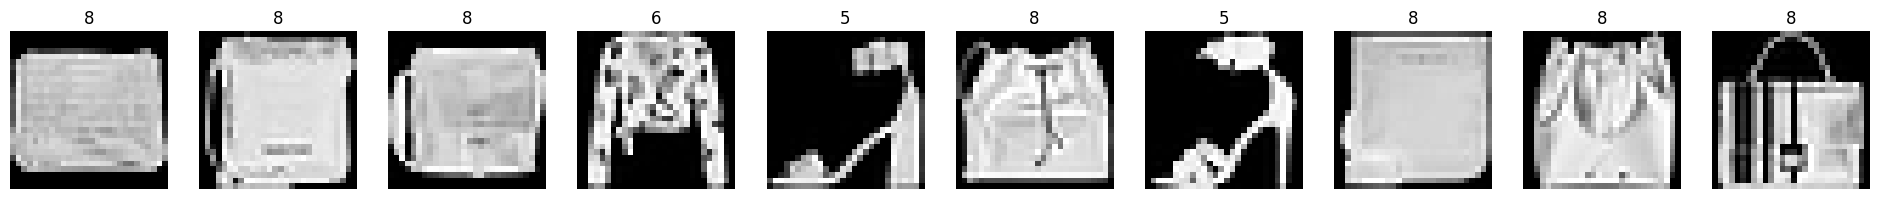

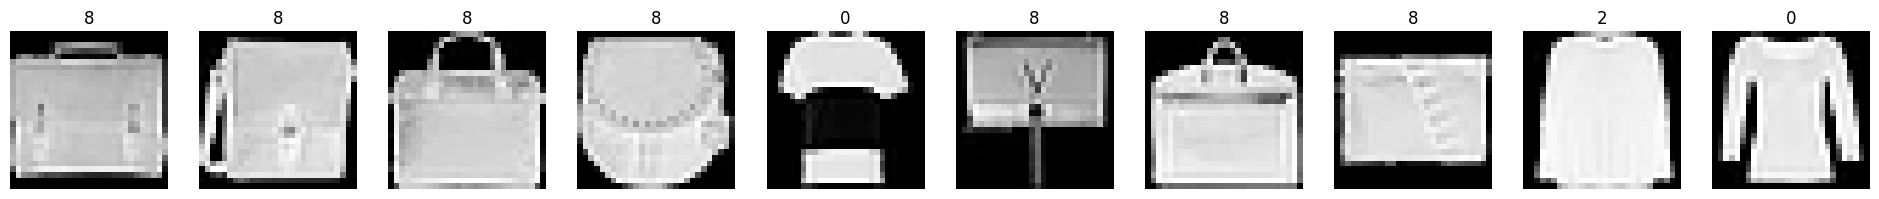

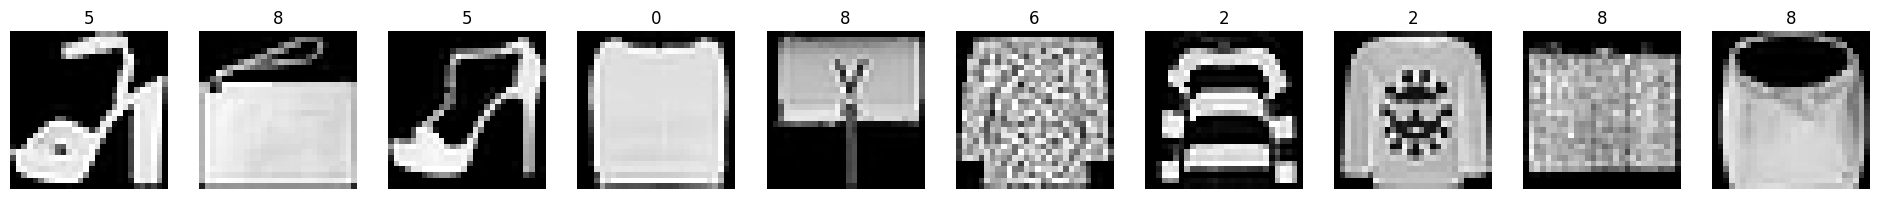

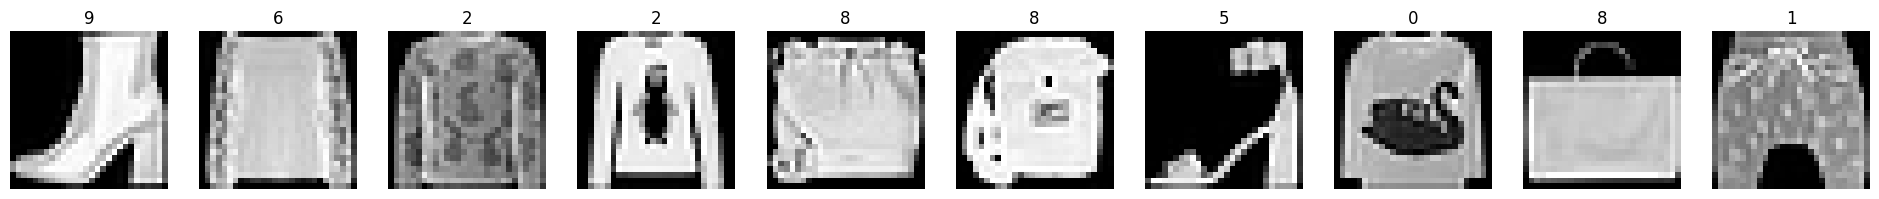

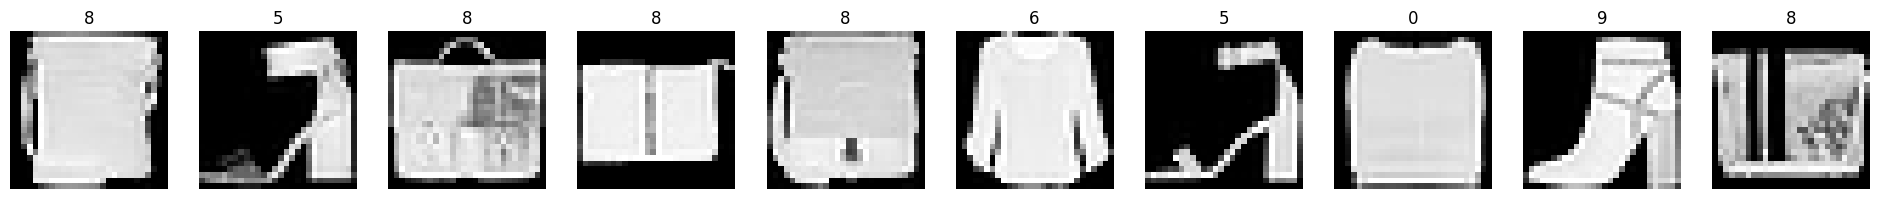

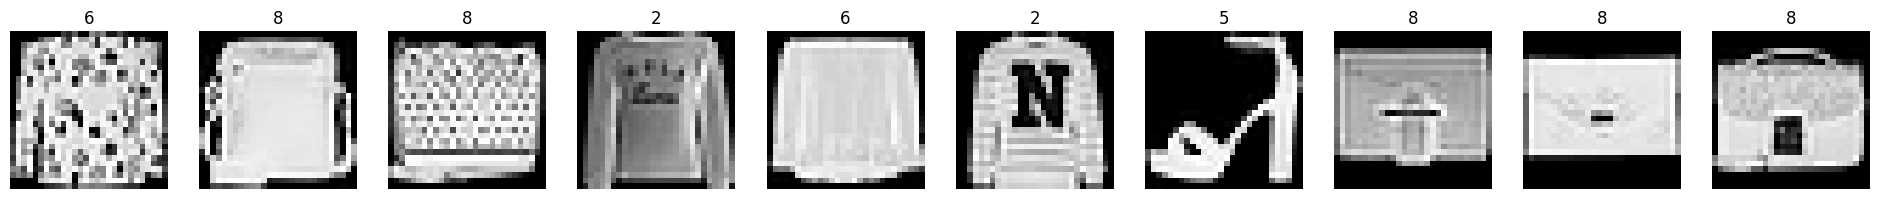

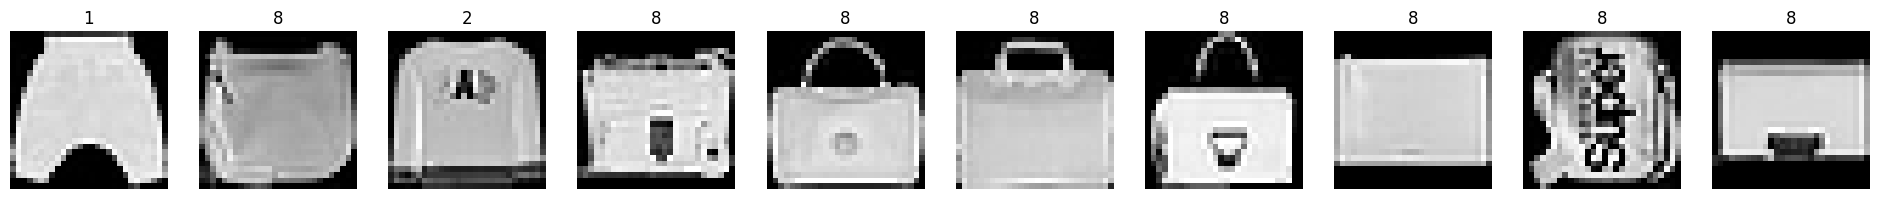

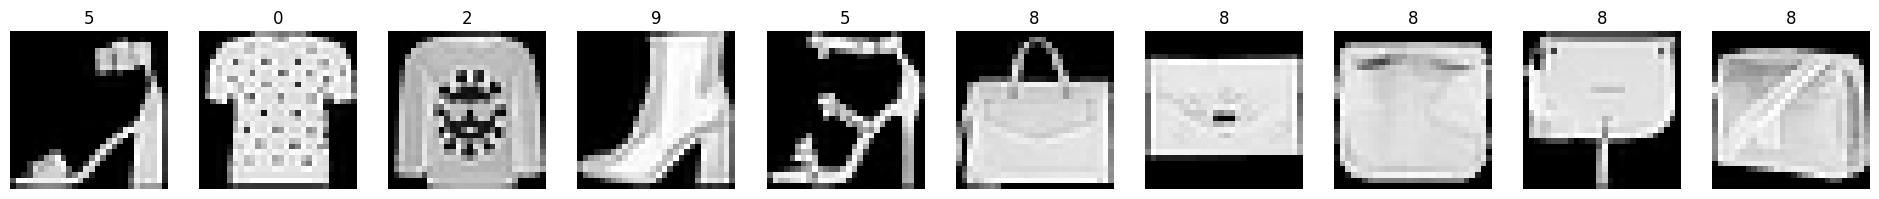

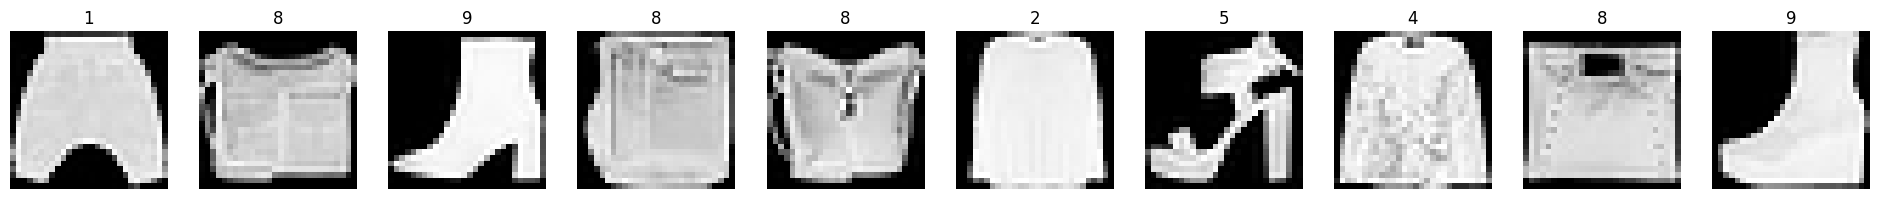

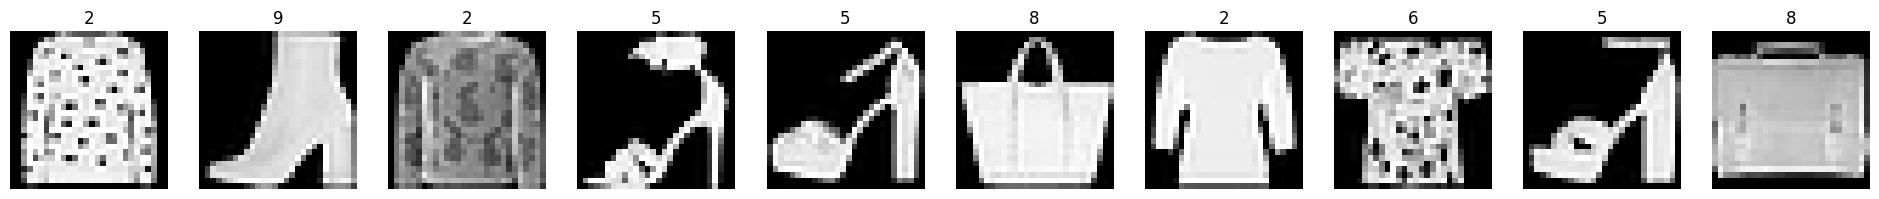

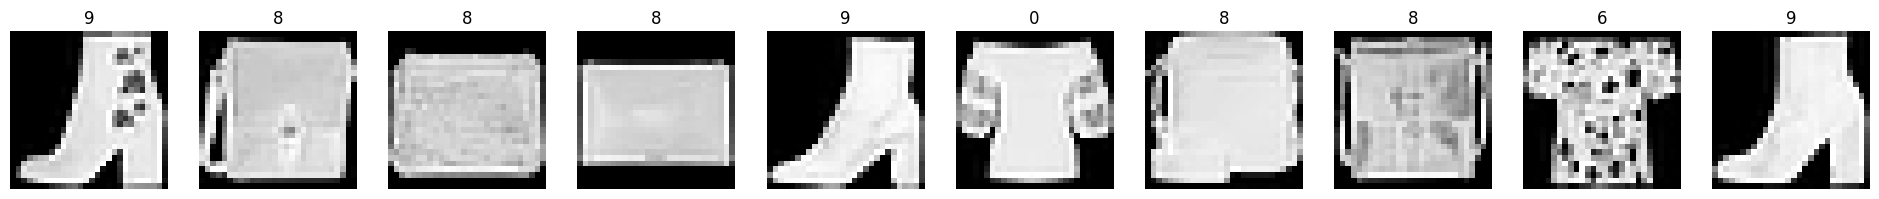

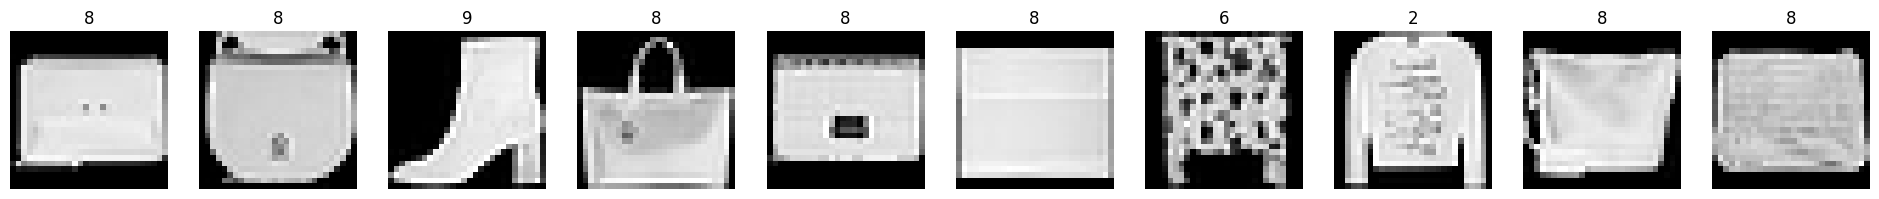

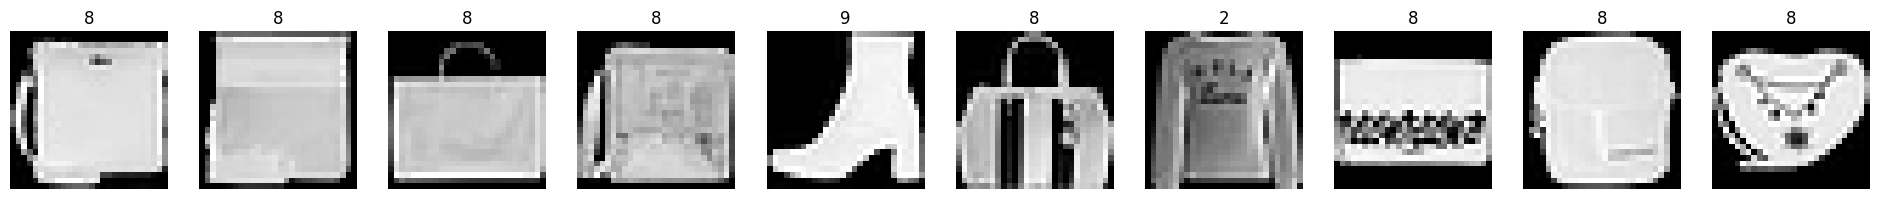

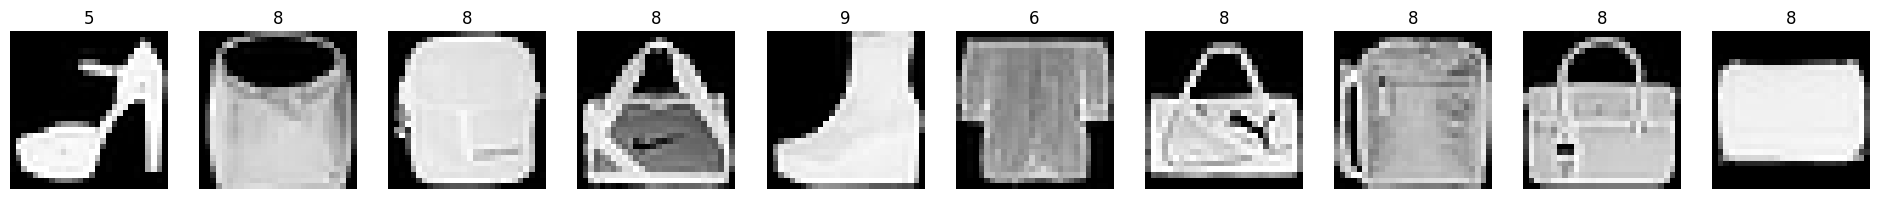

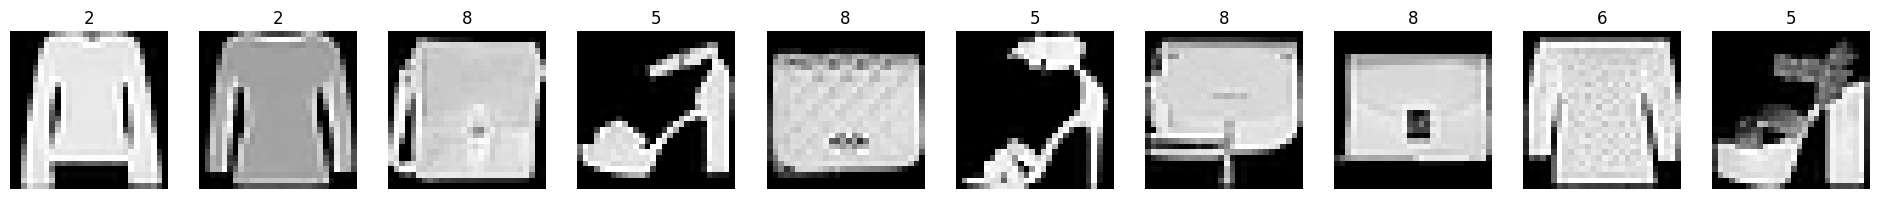

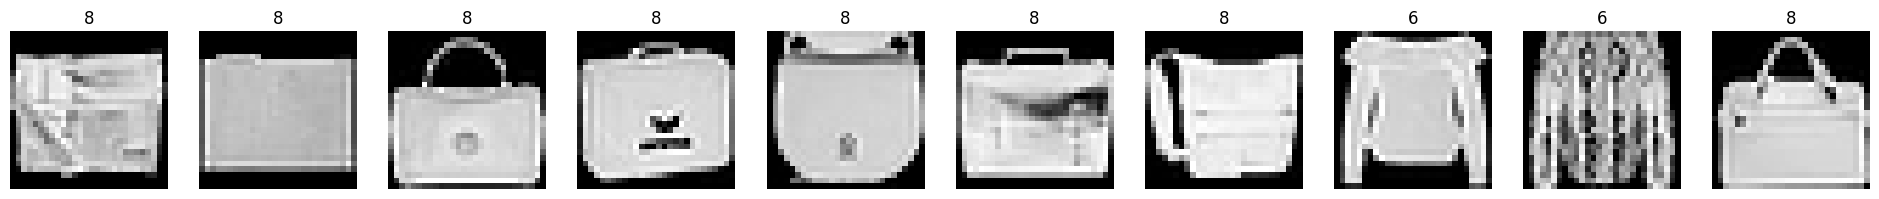

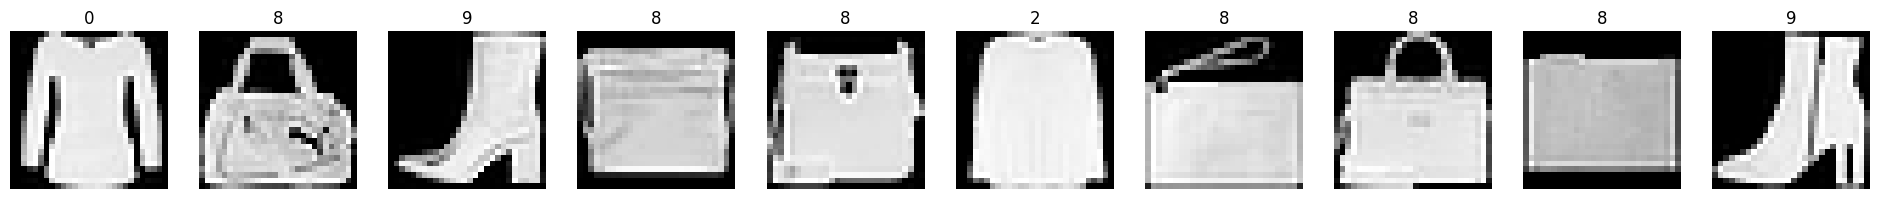

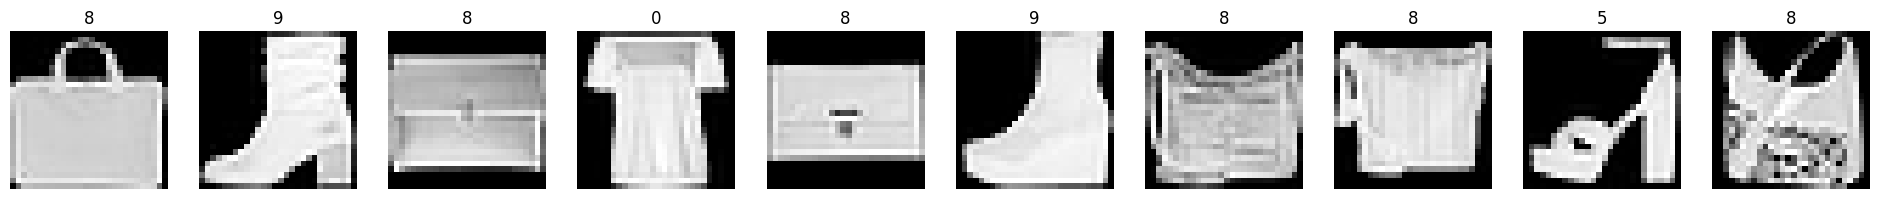

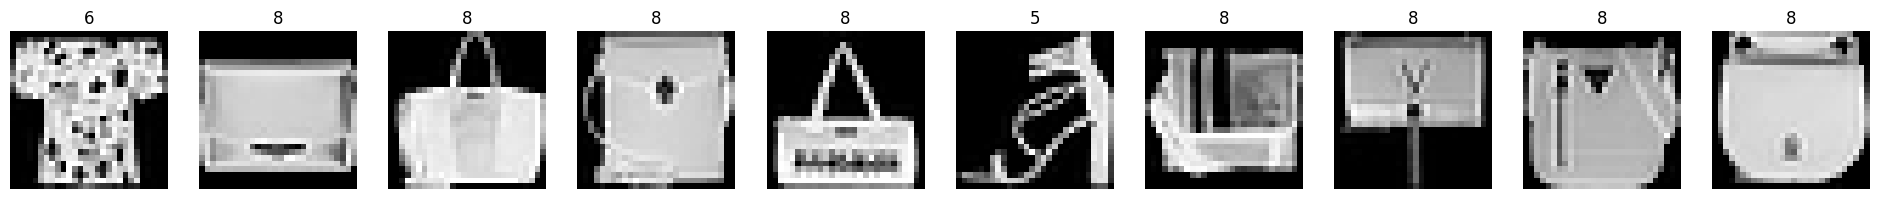

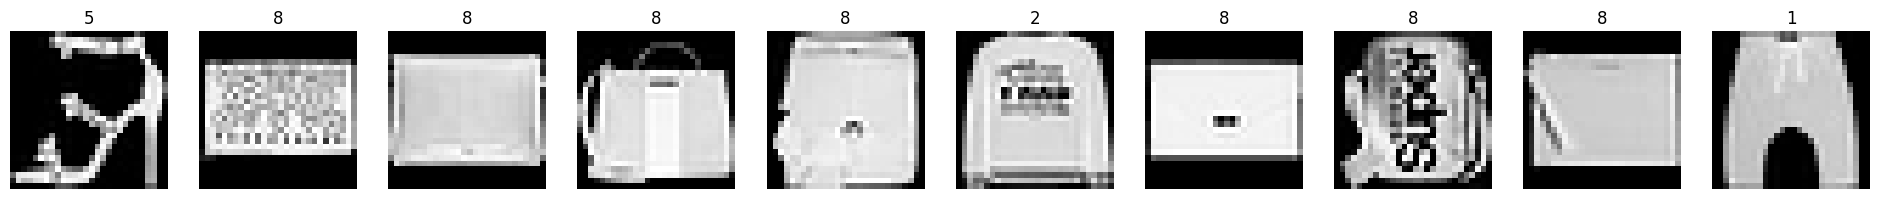

In [56]:
for i in range(30):
    plot_mnist_fashion_images(outliers_mnist_train, outlier_targets, 10, rng)

No out-of-class images found. The $H_0$ rejected.

## Model selection

Based on the fact that the task is a literal substitute for standard MNIST, we presume minimal complexity is necessary. We are going to utilize the same FFN network, just adding Dropout with low probability for educational purposes.

In [58]:
# z normalization, as always for pixels
# .adapt - Keras loops through PyTorch loader to calculate mean/std (axis=None computes a single global mean/std)
normalizer = keras.layers.Normalization(axis=None)
normalizer.adapt(train_loader)

model = keras.Sequential([
    normalizer,                         
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(10, activation="softmax")
])


macro_f1 = keras.metrics.F1Score(average='macro', name='macro_f1')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", macro_f1],
)

ImportError: This requires the tensorflow module. You can install it via `pip install tensorflow`